In [ ]:
"""PyTorch dataset and data-loader helpers for the BreastDM 2D splits.

Expected dataset layout::

    segmentation_DS_7_14_2026/
        train/images/*.jpg
        train/masks/*.png
        val/images/*.jpg
        val/masks/*.png
        test/images/*.jpg
        test/masks/*.png

The returned image has shape ``(3, H, W)`` and the binary mask has shape
``(1, H, W)``. This is compatible with both U-Net and binary UNeXt models.
"""

from __future__ import annotations

import random
from pathlib import Path
from typing import Any, Callable, Mapping, Optional

import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset


Transform = Callable[..., Mapping[str, Any]]


class BreastDMSegmentationDataset(Dataset):
    """Load one BreastDM image and its corresponding binary tumor mask."""

    def __init__(
        self,
        dataset_root: str | Path,
        split: str,
        transform: Optional[Transform] = None,
        mask_threshold: int = 0,
    ) -> None:
        if split not in {"train", "val", "test"}:
            raise ValueError("split must be one of: train, val, test")

        self.dataset_root = Path(dataset_root)
        self.split = split
        self.transform = transform
        self.mask_threshold = mask_threshold
        self.image_dir = self.dataset_root / split / "images"
        self.mask_dir = self.dataset_root / split / "masks"

        if not self.image_dir.is_dir():
            raise FileNotFoundError(f"Image directory not found: {self.image_dir}")
        if not self.mask_dir.is_dir():
            raise FileNotFoundError(f"Mask directory not found: {self.mask_dir}")

        image_by_stem = self._index_files(self.image_dir, {".jpg", ".jpeg", ".png"})
        mask_by_stem = self._index_files(self.mask_dir, {".png", ".jpg", ".jpeg"})

        missing_masks = sorted(set(image_by_stem) - set(mask_by_stem))
        missing_images = sorted(set(mask_by_stem) - set(image_by_stem))
        if missing_masks or missing_images:
            raise ValueError(
                "Image/mask pairing failed. "
                f"Images without masks: {missing_masks[:5]}; "
                f"masks without images: {missing_images[:5]}"
            )

        self.samples = [
            (image_by_stem[stem], mask_by_stem[stem], stem)
            for stem in sorted(image_by_stem)
        ]
        if not self.samples:
            raise ValueError(f"No paired samples found in {self.image_dir}")

    @staticmethod
    def _index_files(directory: Path, extensions: set[str]) -> dict[str, Path]:
        indexed: dict[str, Path] = {}
        for path in directory.iterdir():
            if not path.is_file() or path.suffix.lower() not in extensions:
                continue
            if path.stem in indexed:
                raise ValueError(f"Duplicate filename stem in {directory}: {path.stem}")
            indexed[path.stem] = path
        return indexed

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        image_path, mask_path, sample_id = self.samples[index]

        # UNeXt expects three input channels. Repeating an MRI grayscale image as
        # RGB preserves its values while satisfying that interface.
        image = np.asarray(Image.open(image_path).convert("RGB"), dtype=np.uint8)
        mask = np.asarray(Image.open(mask_path).convert("L"), dtype=np.uint8)

        if image.shape[:2] != mask.shape:
            raise ValueError(
                f"Image/mask size mismatch for {sample_id}: "
                f"{image.shape[:2]} versus {mask.shape}"
            )

        # Compatible with Albumentations Compose(image=..., mask=...).
        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        image_tensor = self._image_to_tensor(image)
        mask_tensor = self._mask_to_tensor(mask, self.mask_threshold)

        metadata = {
            "img_id": sample_id,  # Name retained for original UNeXt compatibility.
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "split": self.split,
        }
        return image_tensor, mask_tensor, metadata

    @staticmethod
    def _image_to_tensor(image: Any) -> torch.Tensor:
        if torch.is_tensor(image):
            tensor = image.float()
            if tensor.ndim != 3:
                raise ValueError(f"Expected a 3D image tensor, received {tensor.shape}")
            # Albumentations without ToTensorV2 returns HWC; ToTensorV2 returns CHW.
            if tensor.shape[0] not in {1, 3} and tensor.shape[-1] in {1, 3}:
                tensor = tensor.permute(2, 0, 1)
            if tensor.max().item() > 1.0:
                tensor = tensor / 255.0
            return tensor.contiguous()

        array = np.asarray(image)
        if array.ndim == 2:
            array = np.repeat(array[..., None], 3, axis=2)
        if array.ndim != 3 or array.shape[2] not in {1, 3}:
            raise ValueError(f"Expected an HWC image, received {array.shape}")
        return torch.from_numpy(array.copy()).permute(2, 0, 1).float().div(255.0)

    @staticmethod
    def _mask_to_tensor(mask: Any, threshold: int) -> torch.Tensor:
        if torch.is_tensor(mask):
            tensor = mask.float()
            if tensor.ndim == 3 and tensor.shape[0] == 1:
                tensor = tensor.squeeze(0)
            elif tensor.ndim == 3 and tensor.shape[-1] == 1:
                tensor = tensor.squeeze(-1)
            if tensor.ndim != 2:
                raise ValueError(f"Expected a 2D binary mask, received {tensor.shape}")
        else:
            tensor = torch.from_numpy(np.asarray(mask).copy()).float()
            if tensor.ndim == 3 and tensor.shape[-1] == 1:
                tensor = tensor.squeeze(-1)
            if tensor.ndim != 2:
                raise ValueError(f"Expected a 2D binary mask, received {tensor.shape}")

        # BreastDM masks use background 0 and positive tumor pixels. Explicit
        # binarization avoids accidental multi-level masks after preprocessing.
        return (tensor > threshold).float().unsqueeze(0).contiguous()


def _seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def create_breastdm_loaders(
    dataset_root: str | Path,
    batch_size: int = 8,
    num_workers: int = 2,
    seed: int = 42,
    train_transform: Optional[Transform] = None,
    eval_transform: Optional[Transform] = None,
    pin_memory: Optional[bool] = None,
) -> dict[str, DataLoader]:
    """Create deterministic train, validation, and test data loaders."""

    if batch_size < 1:
        raise ValueError("batch_size must be at least 1")
    if num_workers < 0:
        raise ValueError("num_workers cannot be negative")

    if pin_memory is None:
        pin_memory = torch.cuda.is_available()

    generator = torch.Generator()
    generator.manual_seed(seed)

    datasets = {
        "train": BreastDMSegmentationDataset(
            dataset_root, "train", transform=train_transform
        ),
        "val": BreastDMSegmentationDataset(
            dataset_root, "val", transform=eval_transform
        ),
        "test": BreastDMSegmentationDataset(
            dataset_root, "test", transform=eval_transform
        ),
    }

    common = {
        "batch_size": batch_size,
        "num_workers": num_workers,
        "pin_memory": pin_memory,
        "worker_init_fn": _seed_worker,
        "generator": generator,
        "persistent_workers": num_workers > 0,
    }

    return {
        "train": DataLoader(datasets["train"], shuffle=True, **common),
        "val": DataLoader(datasets["val"], shuffle=False, **common),
        "test": DataLoader(datasets["test"], shuffle=False, **common),
    }


In [ ]:
# install augmentation package
!pip install -q albumentations

In [ ]:
# mount google drive

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Configure and extract the dataset
# change the path if needed*****
from pathlib import Path
import shutil

DATASET_ZIP = Path(
    "/content/drive/MyDrive/BreastDM_Project/data/segmentation_DS_7_14_2026.zip"
)

DATASET_ROOT = Path(
    "/content/segmentation_DS_7_14_2026"
)

if not DATASET_ZIP.is_file():
    raise FileNotFoundError(
        f"Dataset ZIP was not found:\n{DATASET_ZIP}"
    )

if DATASET_ROOT.is_dir():
    print(f"Dataset is already extracted:\n{DATASET_ROOT}")
else:
    print("Extracting dataset...")
    shutil.unpack_archive(
        filename=str(DATASET_ZIP),
        extract_dir="/content",
    )
    print("Extraction complete.")

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        "Extraction completed, but the expected dataset folder "
        f"was not found:\n{DATASET_ROOT}"
    )

print(f"Dataset root: {DATASET_ROOT}")

Dataset is already extracted:
/content/segmentation_DS_7_14_2026
Dataset root: /content/segmentation_DS_7_14_2026


In [ ]:
# check the folder structure just to be sure

for split in ["train", "val", "test"]:
    image_dir = DATASET_ROOT / split / "images"
    mask_dir = DATASET_ROOT / split / "masks"

    if not image_dir.is_dir():
        raise FileNotFoundError(f"Missing directory: {image_dir}")

    if not mask_dir.is_dir():
        raise FileNotFoundError(f"Missing directory: {mask_dir}")

    image_count = len(list(image_dir.glob("*.jpg")))
    mask_count = len(list(mask_dir.glob("*.png")))

    print(
        f"{split.upper():5} | "
        f"{image_count:,} images | "
        f"{mask_count:,} masks"
    )

    if image_count != mask_count:
        raise ValueError(
            f"{split} has unequal image and mask counts."
        )

TRAIN | 20,417 images | 20,417 masks
VAL   | 4,573 images | 4,573 masks
TEST  | 4,284 images | 4,284 masks


In [ ]:
# Define the image size and transformations

import albumentations as A

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256

train_transform = A.Compose([
    A.Resize(
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
    ),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

eval_transform = A.Compose([
    A.Resize(
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
    ),
])

print("Training transformations:")
print(train_transform)

print("\nEvaluation transformations:")
print(eval_transform)

Training transformations:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.5),
  RandomRotate90(p=0.5),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

Evaluation transformations:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


In [ ]:
# Create the individual datasets
# Uses the BreastDMSegmentationDataset class created
# pretty cool in my opinion I'm going to create dataset classes from now on
train_dataset = BreastDMSegmentationDataset(
    dataset_root=DATASET_ROOT,
    split="train",
    transform=train_transform,
    mask_threshold=0,
)

val_dataset = BreastDMSegmentationDataset(
    dataset_root=DATASET_ROOT,
    split="val",
    transform=eval_transform,
    mask_threshold=0,
)

test_dataset = BreastDMSegmentationDataset(
    dataset_root=DATASET_ROOT,
    split="test",
    transform=eval_transform,
    mask_threshold=0,
)

print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Testing samples:    {len(test_dataset):,}")

Training samples:   20,417
Validation samples: 4,573
Testing samples:    4,284


In [ ]:
# Verify patient separation

def patient_id_from_sample(sample_id):
    parts = sample_id.split("__", 2)

    if len(parts) != 3:
        raise ValueError(
            f"Unexpected sample filename: {sample_id}"
        )

    return parts[0]


def collect_patient_ids(dataset):
    return {
        patient_id_from_sample(sample_id)
        for _, _, sample_id in dataset.samples
    }


train_patients = collect_patient_ids(train_dataset)
val_patients = collect_patient_ids(val_dataset)
test_patients = collect_patient_ids(test_dataset)

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print(f"Training patients:   {len(train_patients)}")
print(f"Validation patients: {len(val_patients)}")
print(f"Testing patients:    {len(test_patients)}")

print("\nPatient overlap:")
print(f"Train/validation: {len(train_val_overlap)}")
print(f"Train/test:       {len(train_test_overlap)}")
print(f"Validation/test:  {len(val_test_overlap)}")

if train_val_overlap or train_test_overlap or val_test_overlap:
    raise ValueError("Patient leakage was detected.")

print("\nPatient-separation verification passed.")

Training patients:   162
Validation patients: 35
Testing patients:    35

Patient overlap:
Train/validation: 0
Train/test:       0
Validation/test:  0

Patient-separation verification passed.


In [ ]:
# inspect one sample

image, mask, metadata = train_dataset[0]

print("Image information")
print("-----------------")
print(f"Shape: {tuple(image.shape)}")
print(f"Type:  {image.dtype}")
print(f"Min:   {image.min().item():.4f}")
print(f"Max:   {image.max().item():.4f}")

print("\nMask information")
print("----------------")
print(f"Shape:         {tuple(mask.shape)}")
print(f"Type:          {mask.dtype}")
print(f"Unique values: {torch.unique(mask).tolist()}")
print(f"Tumor fraction: {mask.mean().item():.6f}")

print("\nMetadata")
print("--------")
print(metadata)

assert image.shape == (
    3,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)

assert mask.shape == (
    1,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)

assert image.dtype == torch.float32
assert mask.dtype == torch.float32
assert image.min() >= 0
assert image.max() <= 1

allowed_mask_values = {0.0, 1.0}
actual_mask_values = set(torch.unique(mask).tolist())

assert actual_mask_values.issubset(
    allowed_mask_values
)

print("\nSingle-sample verification passed.")

Image information
-----------------
Shape: (3, 256, 256)
Type:  torch.float32
Min:   0.0000
Max:   1.0000

Mask information
----------------
Shape:         (1, 256, 256)
Type:          torch.float32
Unique values: [0.0, 1.0]
Tumor fraction: 0.001114

Metadata
--------
{'img_id': 'BreaDM-Be-1801__SUB1__p-032', 'image_path': '/content/segmentation_DS_7_14_2026/train/images/BreaDM-Be-1801__SUB1__p-032.jpg', 'mask_path': '/content/segmentation_DS_7_14_2026/train/masks/BreaDM-Be-1801__SUB1__p-032.png', 'split': 'train'}

Single-sample verification passed.


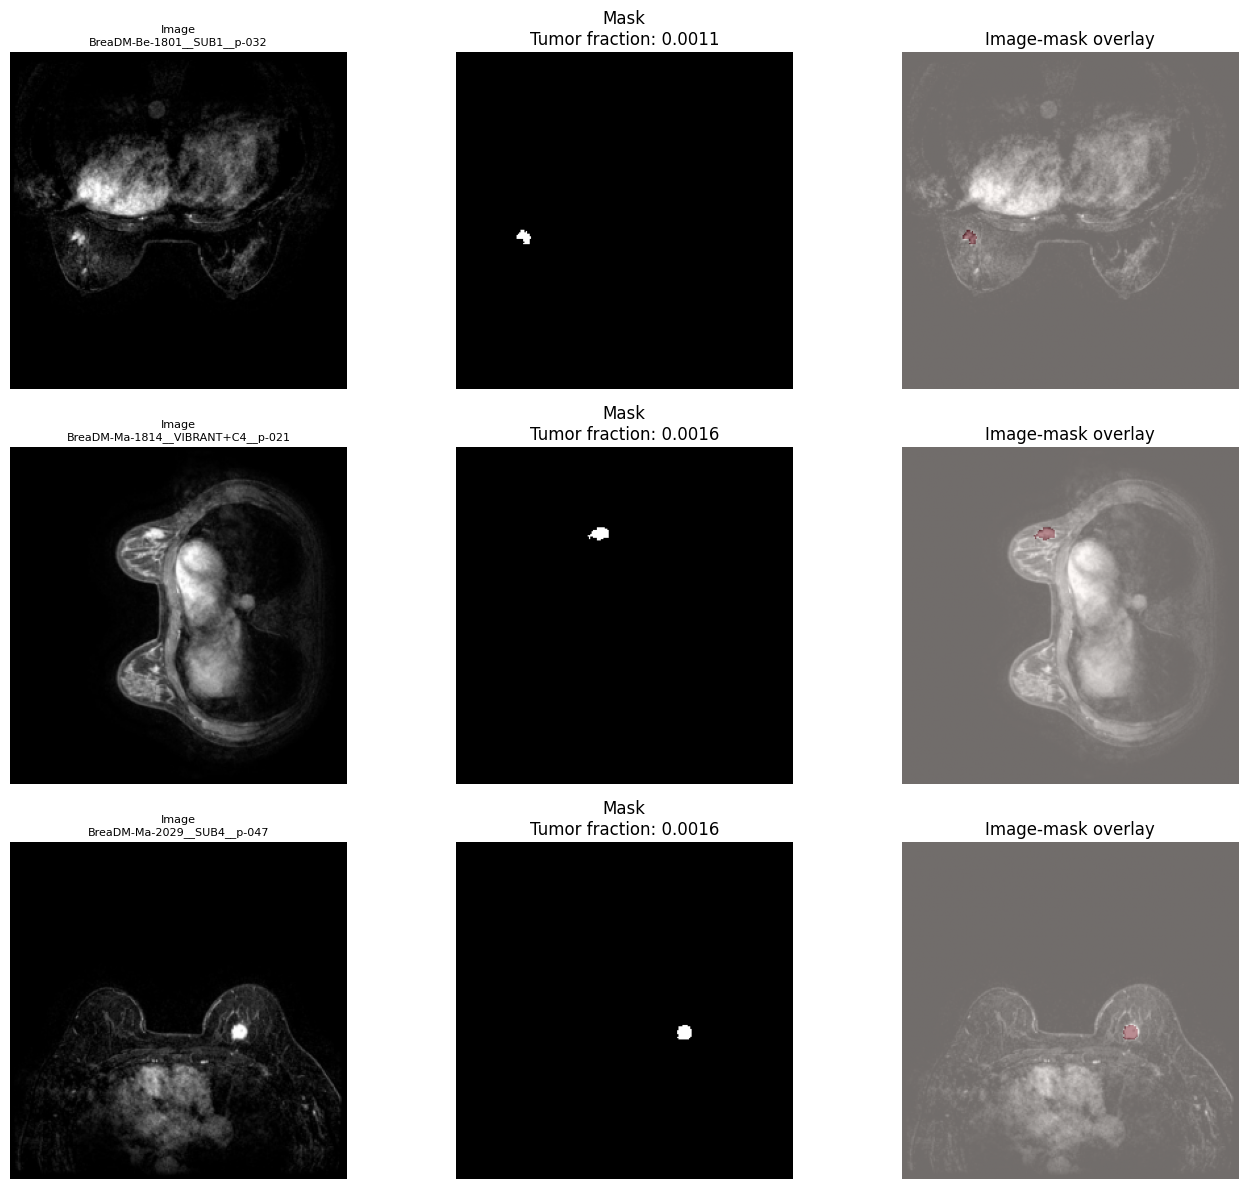

In [ ]:
# visualize image and mask pairs
import matplotlib.pyplot as plt
import numpy as np

sample_indices = [
    0,
    len(train_dataset) // 3,
    (2 * len(train_dataset)) // 3,
]

fig, axes = plt.subplots(
    len(sample_indices),
    3,
    figsize=(14, 12),
)

for row, index in enumerate(sample_indices):
    image, mask, metadata = train_dataset[index]

    image_display = image.permute(1, 2, 0).numpy()
    mask_display = mask.squeeze(0).numpy()

    axes[row, 0].imshow(image_display)
    axes[row, 0].set_title(
        f"Image\n{metadata['img_id']}",
        fontsize=8,
    )

    axes[row, 1].imshow(
        mask_display,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row, 1].set_title(
        f"Mask\nTumor fraction: "
        f"{mask_display.mean():.4f}"
    )

    axes[row, 2].imshow(image_display)
    axes[row, 2].imshow(
        mask_display,
        cmap="Reds",
        alpha=0.45,
        vmin=0,
        vmax=1,
    )
    axes[row, 2].set_title("Image-mask overlay")

    for axis in axes[row]:
        axis.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# create the dataloaders
# these are important variables
BATCH_SIZE = 8
NUM_WORKERS = 2
SEED = 42

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=_seed_worker,
    generator=generator,
    persistent_workers=NUM_WORKERS > 0,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=_seed_worker,
    persistent_workers=NUM_WORKERS > 0,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=_seed_worker,
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Training batches:   {len(train_loader):,}")
print(f"Validation batches: {len(val_loader):,}")
print(f"Testing batches:    {len(test_loader):,}")

Training batches:   2,553
Validation batches: 572
Testing batches:    536


In [ ]:
# test one complete batch!
batch_images, batch_masks, batch_metadata = next(
    iter(train_loader)
)

print(f"Image batch shape: {tuple(batch_images.shape)}")
print(f"Mask batch shape:  {tuple(batch_masks.shape)}")

print(
    f"Image range: "
    f"{batch_images.min().item():.4f} to "
    f"{batch_images.max().item():.4f}"
)

print(
    "Mask values:",
    torch.unique(batch_masks).tolist(),
)

assert batch_images.ndim == 4
assert batch_masks.ndim == 4
assert batch_images.shape[1] == 3
assert batch_masks.shape[1] == 1
assert batch_images.shape[2:] == (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)
assert batch_masks.shape[2:] == (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)

print("\nData-loader batch verification passed.")

Image batch shape: (8, 3, 256, 256)
Mask batch shape:  (8, 1, 256, 256)
Image range: 0.0000 to 1.0000
Mask values: [0.0, 1.0]

Data-loader batch verification passed.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# STOCHASTIC DEPTH
# ============================================================

def drop_path(
    x,
    drop_probability=0.0,
    training=False,
):
    """
    Drop complete residual paths during training.

    This is also called stochastic depth.
    """

    if drop_probability == 0.0 or not training:
        return x

    keep_probability = 1.0 - drop_probability

    shape = (
        x.shape[0],
        *([1] * (x.ndim - 1)),
    )

    random_tensor = keep_probability + torch.rand(
        shape,
        dtype=x.dtype,
        device=x.device,
    )

    random_tensor.floor_()

    return (
        x.div(keep_probability)
        * random_tensor
    )


class DropPath(nn.Module):
    """Stochastic-depth layer."""

    def __init__(self, drop_probability=0.0):
        super().__init__()

        self.drop_probability = drop_probability

    def forward(self, x):
        return drop_path(
            x,
            drop_probability=self.drop_probability,
            training=self.training,
        )


# ============================================================
# WEIGHT INITIALIZATION
# ============================================================

def initialize_weights(module):
    """Initialize UNeXt layers."""

    if isinstance(module, nn.Linear):
        nn.init.trunc_normal_(
            module.weight,
            std=0.02,
        )

        if module.bias is not None:
            nn.init.constant_(
                module.bias,
                0,
            )

    elif isinstance(module, nn.LayerNorm):
        nn.init.constant_(
            module.bias,
            0,
        )

        nn.init.constant_(
            module.weight,
            1.0,
        )

    elif isinstance(module, nn.Conv2d):
        fan_out = (
            module.kernel_size[0]
            * module.kernel_size[1]
            * module.out_channels
        )

        fan_out //= module.groups

        module.weight.data.normal_(
            0,
            (2.0 / fan_out) ** 0.5,
        )

        if module.bias is not None:
            module.bias.data.zero_()


# ============================================================
# DEPTHWISE CONVOLUTION
# ============================================================

class DWConv(nn.Module):
    """
    Depthwise convolution used inside each shifted MLP block.
    """

    def __init__(self, channels):
        super().__init__()

        self.depthwise_conv = nn.Conv2d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=3,
            stride=1,
            padding=1,
            groups=channels,
            bias=True,
        )

    def forward(self, x, height, width):
        batch_size, _, channels = x.shape

        x = x.transpose(1, 2).reshape(
            batch_size,
            channels,
            height,
            width,
        )

        x = self.depthwise_conv(x)

        x = x.flatten(2).transpose(1, 2)

        return x


# ============================================================
# SHIFTED MLP
# ============================================================

class ShiftMLP(nn.Module):
    """
    UNeXt shifted MLP.

    Features are shifted vertically before the first linear
    projection and horizontally before the second projection.
    """

    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        activation_layer=nn.GELU,
        dropout=0.0,
        shift_size=5,
    ):
        super().__init__()

        hidden_features = (
            hidden_features
            if hidden_features is not None
            else in_features
        )

        out_features = (
            out_features
            if out_features is not None
            else in_features
        )

        if shift_size % 2 == 0:
            raise ValueError(
                "shift_size must be an odd number."
            )

        self.shift_size = shift_size
        self.padding = shift_size // 2

        self.fc1 = nn.Linear(
            in_features,
            hidden_features,
        )

        self.depthwise_conv = DWConv(
            hidden_features
        )

        self.activation = activation_layer()

        self.fc2 = nn.Linear(
            hidden_features,
            out_features,
        )

        self.dropout = nn.Dropout(dropout)

        self.apply(initialize_weights)

    def _shift_channels(
        self,
        x,
        height,
        width,
        spatial_dimension,
    ):
        """
        Divide channels into groups and shift each group by
        a different spatial offset.
        """

        batch_size, channels, _, _ = x.shape

        x = F.pad(
            x,
            (
                self.padding,
                self.padding,
                self.padding,
                self.padding,
            ),
            mode="constant",
            value=0,
        )

        channel_groups = torch.chunk(
            x,
            self.shift_size,
            dim=1,
        )

        shift_values = range(
            -self.padding,
            self.padding + 1,
        )

        shifted_groups = [
            torch.roll(
                channel_group,
                shifts=shift_value,
                dims=spatial_dimension,
            )
            for channel_group, shift_value
            in zip(channel_groups, shift_values)
        ]

        x = torch.cat(
            shifted_groups,
            dim=1,
        )

        x = torch.narrow(
            x,
            dim=2,
            start=self.padding,
            length=height,
        )

        x = torch.narrow(
            x,
            dim=3,
            start=self.padding,
            length=width,
        )

        if x.shape[1] != channels:
            raise RuntimeError(
                "Channel shifting changed the channel count."
            )

        return x

    def forward(self, x, height, width):
        batch_size, _, channels = x.shape

        # Convert tokens into a feature map.
        x = x.transpose(1, 2).reshape(
            batch_size,
            channels,
            height,
            width,
        )

        # Shift channel groups vertically.
        x = self._shift_channels(
            x=x,
            height=height,
            width=width,
            spatial_dimension=2,
        )

        # Convert the feature map back into tokens.
        x = x.reshape(
            batch_size,
            channels,
            height * width,
        ).transpose(1, 2)

        x = self.fc1(x)

        x = self.depthwise_conv(
            x,
            height,
            width,
        )

        x = self.activation(x)
        x = self.dropout(x)

        hidden_channels = x.shape[-1]

        x = x.transpose(1, 2).reshape(
            batch_size,
            hidden_channels,
            height,
            width,
        )

        # Shift channel groups horizontally.
        x = self._shift_channels(
            x=x,
            height=height,
            width=width,
            spatial_dimension=3,
        )

        x = x.reshape(
            batch_size,
            hidden_channels,
            height * width,
        ).transpose(1, 2)

        x = self.fc2(x)
        x = self.dropout(x)

        return x


# ============================================================
# SHIFTED MLP RESIDUAL BLOCK
# ============================================================

class ShiftedBlock(nn.Module):
    """Layer normalization, shifted MLP, and residual connection."""

    def __init__(
        self,
        dimension,
        mlp_ratio=1.0,
        dropout=0.0,
        drop_path_probability=0.0,
        normalization_layer=nn.LayerNorm,
    ):
        super().__init__()

        hidden_dimension = int(
            dimension * mlp_ratio
        )

        self.normalization = normalization_layer(
            dimension
        )

        self.mlp = ShiftMLP(
            in_features=dimension,
            hidden_features=hidden_dimension,
            out_features=dimension,
            dropout=dropout,
        )

        if drop_path_probability > 0:
            self.drop_path = DropPath(
                drop_path_probability
            )
        else:
            self.drop_path = nn.Identity()

        self.apply(initialize_weights)

    def forward(self, x, height, width):
        residual = x

        x = self.normalization(x)

        x = self.mlp(
            x,
            height,
            width,
        )

        x = residual + self.drop_path(x)

        return x


# ============================================================
# OVERLAPPING PATCH EMBEDDING
# ============================================================

class OverlapPatchEmbed(nn.Module):
    """
    Convert a feature map into overlapping image-patch tokens.
    """

    def __init__(
        self,
        patch_size=3,
        stride=2,
        input_channels=3,
        embedding_dimension=768,
    ):
        super().__init__()

        self.projection = nn.Conv2d(
            in_channels=input_channels,
            out_channels=embedding_dimension,
            kernel_size=patch_size,
            stride=stride,
            padding=patch_size // 2,
        )

        self.normalization = nn.LayerNorm(
            embedding_dimension
        )

        self.apply(initialize_weights)

    def forward(self, x):
        x = self.projection(x)

        _, _, height, width = x.shape

        x = x.flatten(2).transpose(1, 2)
        x = self.normalization(x)

        return x, height, width


# ============================================================
# COMPLETE UNEXT MODEL
# ============================================================

class UNext(nn.Module):
    """
    UNeXt for binary or multiclass image segmentation.

    Encoder:
        3 convolutional stages
        2 tokenized shifted-MLP stages

    Decoder:
        5 upsampling stages
        Additive skip connections
        2 shifted-MLP decoding blocks

    The model returns raw logits. Do not apply sigmoid inside
    the model when using BCEWithLogitsLoss.
    """

    def __init__(
        self,
        num_classes=1,
        input_channels=3,
        embedding_dimensions=(32, 64, 128),
        dropout=0.0,
        drop_path_rate=0.0,
    ):
        super().__init__()

        if len(embedding_dimensions) != 3:
            raise ValueError(
                "embedding_dimensions must contain "
                "exactly three values."
            )

        embed_1, embed_2, embed_3 = (
            embedding_dimensions
        )

        # The original architecture uses:
        # embed_1 = 32, embed_2 = 64, embed_3 = 128.
        if (
            embed_1 != 32
            or embed_2 != 64
            or embed_3 != 128
        ):
            raise ValueError(
                "This reproduction expects embedding dimensions "
                "(32, 64, 128)."
            )

        # ----------------------------------------------------
        # Convolutional encoder
        # ----------------------------------------------------

        self.encoder1 = nn.Conv2d(
            input_channels,
            8,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.encoder2 = nn.Conv2d(
            8,
            16,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.encoder3 = nn.Conv2d(
            16,
            32,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.encoder_bn1 = nn.BatchNorm2d(8)
        self.encoder_bn2 = nn.BatchNorm2d(16)
        self.encoder_bn3 = nn.BatchNorm2d(32)

        # ----------------------------------------------------
        # Tokenized MLP encoder
        # ----------------------------------------------------

        self.patch_embed3 = OverlapPatchEmbed(
            patch_size=3,
            stride=2,
            input_channels=32,
            embedding_dimension=64,
        )

        self.encoder_mlp1 = ShiftedBlock(
            dimension=64,
            mlp_ratio=1.0,
            dropout=dropout,
            drop_path_probability=0.0,
        )

        self.encoder_norm3 = nn.LayerNorm(64)

        self.patch_embed4 = OverlapPatchEmbed(
            patch_size=3,
            stride=2,
            input_channels=64,
            embedding_dimension=128,
        )

        self.encoder_mlp2 = ShiftedBlock(
            dimension=128,
            mlp_ratio=1.0,
            dropout=dropout,
            drop_path_probability=drop_path_rate,
        )

        self.encoder_norm4 = nn.LayerNorm(128)

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        self.decoder1 = nn.Conv2d(
            128,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.decoder_bn1 = nn.BatchNorm2d(64)

        self.decoder_mlp1 = ShiftedBlock(
            dimension=64,
            mlp_ratio=1.0,
            dropout=dropout,
            drop_path_probability=0.0,
        )

        self.decoder_norm3 = nn.LayerNorm(64)

        self.decoder2 = nn.Conv2d(
            64,
            32,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.decoder_bn2 = nn.BatchNorm2d(32)

        self.decoder_mlp2 = ShiftedBlock(
            dimension=32,
            mlp_ratio=1.0,
            dropout=dropout,
            drop_path_probability=drop_path_rate,
        )

        self.decoder_norm4 = nn.LayerNorm(32)

        self.decoder3 = nn.Conv2d(
            32,
            16,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.decoder_bn3 = nn.BatchNorm2d(16)

        self.decoder4 = nn.Conv2d(
            16,
            8,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.decoder_bn4 = nn.BatchNorm2d(8)

        self.decoder5 = nn.Conv2d(
            8,
            8,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.final = nn.Conv2d(
            8,
            num_classes,
            kernel_size=1,
        )

    @staticmethod
    def _tokens_to_feature_map(
        tokens,
        batch_size,
        height,
        width,
    ):
        return tokens.reshape(
            batch_size,
            height,
            width,
            -1,
        ).permute(
            0,
            3,
            1,
            2,
        ).contiguous()

    @staticmethod
    def _upsample_to(
        x,
        target,
    ):
        """
        Bilinearly resize x to the spatial size of target.

        Using the target size directly is safer than assuming
        every input dimension divides perfectly by two.
        """

        return F.interpolate(
            x,
            size=target.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    def forward(self, x):
        input_height, input_width = x.shape[-2:]
        batch_size = x.shape[0]

        # ----------------------------------------------------
        # Encoder stage 1
        # Output resolution: 1/2
        # ----------------------------------------------------

        x = self.encoder1(x)
        x = self.encoder_bn1(x)
        x = F.max_pool2d(
            x,
            kernel_size=2,
            stride=2,
        )
        x = F.relu(x, inplace=False)

        skip1 = x

        # ----------------------------------------------------
        # Encoder stage 2
        # Output resolution: 1/4
        # ----------------------------------------------------

        x = self.encoder2(x)
        x = self.encoder_bn2(x)
        x = F.max_pool2d(
            x,
            kernel_size=2,
            stride=2,
        )
        x = F.relu(x, inplace=False)

        skip2 = x

        # ----------------------------------------------------
        # Encoder stage 3
        # Output resolution: 1/8
        # ----------------------------------------------------

        x = self.encoder3(x)
        x = self.encoder_bn3(x)
        x = F.max_pool2d(
            x,
            kernel_size=2,
            stride=2,
        )
        x = F.relu(x, inplace=False)

        skip3 = x

        # ----------------------------------------------------
        # Tokenized MLP stage 1
        # Output resolution: 1/16
        # ----------------------------------------------------

        x, height, width = self.patch_embed3(x)

        x = self.encoder_mlp1(
            x,
            height,
            width,
        )

        x = self.encoder_norm3(x)

        x = self._tokens_to_feature_map(
            x,
            batch_size,
            height,
            width,
        )

        skip4 = x

        # ----------------------------------------------------
        # Tokenized MLP bottleneck
        # Output resolution: 1/32
        # ----------------------------------------------------

        x, height, width = self.patch_embed4(x)

        x = self.encoder_mlp2(
            x,
            height,
            width,
        )

        x = self.encoder_norm4(x)

        x = self._tokens_to_feature_map(
            x,
            batch_size,
            height,
            width,
        )

        # ----------------------------------------------------
        # Decoder stage 1: 1/32 -> 1/16
        # ----------------------------------------------------

        x = self.decoder1(x)
        x = self.decoder_bn1(x)
        x = self._upsample_to(x, skip4)
        x = F.relu(x, inplace=False)

        x = x + skip4

        height, width = x.shape[-2:]

        x = x.flatten(2).transpose(1, 2)

        x = self.decoder_mlp1(
            x,
            height,
            width,
        )

        x = self.decoder_norm3(x)

        x = self._tokens_to_feature_map(
            x,
            batch_size,
            height,
            width,
        )

        # ----------------------------------------------------
        # Decoder stage 2: 1/16 -> 1/8
        # ----------------------------------------------------

        x = self.decoder2(x)
        x = self.decoder_bn2(x)
        x = self._upsample_to(x, skip3)
        x = F.relu(x, inplace=False)

        x = x + skip3

        height, width = x.shape[-2:]

        x = x.flatten(2).transpose(1, 2)

        x = self.decoder_mlp2(
            x,
            height,
            width,
        )

        x = self.decoder_norm4(x)

        x = self._tokens_to_feature_map(
            x,
            batch_size,
            height,
            width,
        )

        # ----------------------------------------------------
        # Decoder stage 3: 1/8 -> 1/4
        # ----------------------------------------------------

        x = self.decoder3(x)
        x = self.decoder_bn3(x)
        x = self._upsample_to(x, skip2)
        x = F.relu(x, inplace=False)

        x = x + skip2

        # ----------------------------------------------------
        # Decoder stage 4: 1/4 -> 1/2
        # ----------------------------------------------------

        x = self.decoder4(x)
        x = self.decoder_bn4(x)
        x = self._upsample_to(x, skip1)
        x = F.relu(x, inplace=False)

        x = x + skip1

        # ----------------------------------------------------
        # Decoder stage 5: 1/2 -> original resolution
        # ----------------------------------------------------

        x = self.decoder5(x)

        x = F.interpolate(
            x,
            size=(input_height, input_width),
            mode="bilinear",
            align_corners=False,
        )

        x = F.relu(x, inplace=False)

        # Raw segmentation logits
        logits = self.final(x)

        return logits


print("UNeXt architecture defined successfully.")

UNeXt architecture defined successfully.


In [ ]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = UNext(
    num_classes=1,
    input_channels=3,
    embedding_dimensions=(32, 64, 128),
    dropout=0.0,
    drop_path_rate=0.0,
).to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Device: {DEVICE}")
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Device: cuda
Total parameters: 253,561
Trainable parameters: 253,561


In [ ]:
# one batch + checking the sizes for confirmation + smoke test
# effectively checking the UNEXt forward pass to make sure it works before we actually start using the full model

model.eval()

smoke_test_images = batch_images[:2].to(
    DEVICE,
    non_blocking=True,
)

smoke_test_masks = batch_masks[:2].to(
    DEVICE,
    non_blocking=True,
)

with torch.no_grad():
    smoke_test_logits = model(
        smoke_test_images
    )

print(
    "Input shape: ",
    tuple(smoke_test_images.shape),
)

print(
    "Output shape:",
    tuple(smoke_test_logits.shape),
)

print(
    "Mask shape:  ",
    tuple(smoke_test_masks.shape),
)

print(
    "Output range:",
    f"{smoke_test_logits.min().item():.4f}",
    "to",
    f"{smoke_test_logits.max().item():.4f}",
)

assert smoke_test_logits.shape == (
    smoke_test_masks.shape
), (
    "UNeXt output shape does not match "
    "the target-mask shape."
)

assert torch.isfinite(
    smoke_test_logits
).all(), (
    "The model produced NaN or infinite values."
)

print("\nUNeXt forward-pass verification passed.")

Input shape:  (2, 3, 256, 256)
Output shape: (2, 1, 256, 256)
Mask shape:   (2, 1, 256, 256)
Output range: 0.2225 to 0.3449

UNeXt forward-pass verification passed.


In [ ]:
# define BCE-dice loss
import torch
import torch.nn as nn
import torch.nn.functional as F


class BCEDiceLoss(nn.Module):
    """
    Combined binary cross-entropy and soft Dice loss.

    UNeXt returns raw logits. BCEWithLogits handles sigmoid
    internally, while Dice loss applies sigmoid explicitly.
    """

    def __init__(
        self,
        bce_weight=0.5,
        dice_weight=1.0,
        smooth=1e-5,
    ):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

    def forward(self, logits, targets):
        if logits.shape != targets.shape:
            raise ValueError(
                f"Prediction shape {tuple(logits.shape)} "
                f"does not match target shape "
                f"{tuple(targets.shape)}."
            )

        targets = targets.float()

        bce_loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
        )

        probabilities = torch.sigmoid(logits)

        probabilities = probabilities.flatten(
            start_dim=1
        )

        targets_flat = targets.flatten(
            start_dim=1
        )

        intersection = (
            probabilities * targets_flat
        ).sum(dim=1)

        denominator = (
            probabilities.sum(dim=1)
            + targets_flat.sum(dim=1)
        )

        dice_score = (
            2.0 * intersection + self.smooth
        ) / (
            denominator + self.smooth
        )

        dice_loss = 1.0 - dice_score.mean()

        total_loss = (
            self.bce_weight * bce_loss
            + self.dice_weight * dice_loss
        )

        return total_loss


criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=1.0,
    smooth=1e-5,
)

print("BCE–Dice loss defined successfully.")

BCE–Dice loss defined successfully.


In [ ]:
# define dice and IoU metrics
@torch.no_grad()
def binary_segmentation_metrics(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-7,
):
    """
    Calculate mean binary Dice and IoU scores.

    Args:
        logits:
            Raw model outputs with shape [B, 1, H, W].

        targets:
            Binary masks with shape [B, 1, H, W].

        threshold:
            Probability threshold used to create binary masks.

    Returns:
        Dictionary containing mean Dice and IoU.
    """

    if logits.shape != targets.shape:
        raise ValueError(
            f"Prediction shape {tuple(logits.shape)} "
            f"does not match target shape "
            f"{tuple(targets.shape)}."
        )

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    targets = (
        targets >= 0.5
    ).float()

    predictions = predictions.flatten(
        start_dim=1
    )

    targets = targets.flatten(
        start_dim=1
    )

    intersection = (
        predictions * targets
    ).sum(dim=1)

    prediction_pixels = predictions.sum(dim=1)
    target_pixels = targets.sum(dim=1)

    union = (
        prediction_pixels
        + target_pixels
        - intersection
    )

    dice = (
        2.0 * intersection + smooth
    ) / (
        prediction_pixels
        + target_pixels
        + smooth
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
    }


print("Dice and IoU metrics defined successfully.")

Dice and IoU metrics defined successfully.


In [ ]:
# Run one optimization step
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Use a separate model for debugging.
debug_model = UNext(
    num_classes=1,
    input_channels=3,
    embedding_dimensions=(32, 64, 128),
    dropout=0.0,
    drop_path_rate=0.0,
).to(DEVICE)

debug_optimizer = torch.optim.Adam(
    debug_model.parameters(),
    lr=1e-3,
)

debug_images = batch_images[:4].to(
    DEVICE,
    non_blocking=True,
)

debug_masks = batch_masks[:4].to(
    DEVICE,
    non_blocking=True,
)

# Save one parameter tensor before optimization.
parameter_before = next(
    debug_model.parameters()
).detach().clone()

debug_model.train()

debug_optimizer.zero_grad(
    set_to_none=True
)

debug_logits = debug_model(
    debug_images
)

debug_loss = criterion(
    debug_logits,
    debug_masks,
)

if not torch.isfinite(debug_loss):
    raise RuntimeError(
        f"Loss is not finite: {debug_loss.item()}"
    )

debug_loss.backward()

gradient_norm = torch.nn.utils.clip_grad_norm_(
    debug_model.parameters(),
    max_norm=5.0,
)

if not torch.isfinite(gradient_norm):
    raise RuntimeError(
        f"Gradient norm is not finite: {gradient_norm}"
    )

debug_optimizer.step()

parameter_after = next(
    debug_model.parameters()
).detach().clone()

parameter_change = (
    parameter_after - parameter_before
).abs().sum().item()

metrics = binary_segmentation_metrics(
    debug_logits.detach(),
    debug_masks,
)

print(f"Device:           {DEVICE}")
print(f"Loss:             {debug_loss.item():.6f}")
print(f"Gradient norm:    {gradient_norm.item():.6f}")
print(f"Parameter change: {parameter_change:.8f}")
print(f"Dice:             {metrics['dice']:.6f}")
print(f"IoU:              {metrics['iou']:.6f}")

assert debug_logits.shape == debug_masks.shape
assert torch.isfinite(debug_logits).all()
assert parameter_change > 0

print("\nOne-step optimization verification passed.")

Device:           cuda
Loss:             1.340058
Gradient norm:    0.842174
Parameter change: 0.21598104
Dice:             0.027399
IoU:              0.013946

One-step optimization verification passed.


In [ ]:
# initialize a clean model for overfitting test
# Delete the previous debug model and release its GPU memory.
del debug_model
del debug_optimizer

if torch.cuda.is_available():
    torch.cuda.empty_cache()

overfit_model = UNext(
    num_classes=1,
    input_channels=3,
    embedding_dimensions=(32, 64, 128),
    dropout=0.0,
    drop_path_rate=0.0,
).to(DEVICE)

overfit_optimizer = torch.optim.Adam(
    overfit_model.parameters(),
    lr=1e-3,
)

print("Clean overfitting model initialized.")

Clean overfitting model initialized.


In [ ]:
# Overfit the finy dataset
OVERFIT_EPOCHS = 100

overfit_history = {
    "loss": [],
    "dice": [],
    "iou": [],
}

for epoch in range(1, OVERFIT_EPOCHS + 1):
    overfit_model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    samples_seen = 0

    for images, masks, metadata in overfit_loader:
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True,
        )

        overfit_optimizer.zero_grad(
            set_to_none=True
        )

        logits = overfit_model(images)

        loss = criterion(
            logits,
            masks,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss detected at "
                f"epoch {epoch}."
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            overfit_model.parameters(),
            max_norm=5.0,
        )

        overfit_optimizer.step()

        metrics = binary_segmentation_metrics(
            logits.detach(),
            masks,
        )

        current_batch_size = images.shape[0]

        running_loss += (
            loss.item() * current_batch_size
        )

        running_dice += (
            metrics["dice"] * current_batch_size
        )

        running_iou += (
            metrics["iou"] * current_batch_size
        )

        samples_seen += current_batch_size

    epoch_loss = running_loss / samples_seen
    epoch_dice = running_dice / samples_seen
    epoch_iou = running_iou / samples_seen

    overfit_history["loss"].append(
        epoch_loss
    )

    overfit_history["dice"].append(
        epoch_dice
    )

    overfit_history["iou"].append(
        epoch_iou
    )

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d}/{OVERFIT_EPOCHS} | "
            f"Loss: {epoch_loss:.6f} | "
            f"Dice: {epoch_dice:.4f} | "
            f"IoU: {epoch_iou:.4f}"
        )

Epoch   1/100 | Loss: 1.438568 | Dice: 0.0038 | IoU: 0.0019
Epoch  10/100 | Loss: 1.061352 | Dice: 0.0000 | IoU: 0.0000
Epoch  20/100 | Loss: 0.992054 | Dice: 0.0000 | IoU: 0.0000
Epoch  30/100 | Loss: 0.312299 | Dice: 0.8334 | IoU: 0.7163
Epoch  40/100 | Loss: 0.157828 | Dice: 0.8742 | IoU: 0.7773
Epoch  50/100 | Loss: 0.129663 | Dice: 0.8919 | IoU: 0.8054
Epoch  60/100 | Loss: 0.117591 | Dice: 0.9006 | IoU: 0.8198
Epoch  70/100 | Loss: 0.112050 | Dice: 0.9052 | IoU: 0.8275
Epoch  80/100 | Loss: 0.096658 | Dice: 0.9184 | IoU: 0.8499
Epoch  90/100 | Loss: 0.097171 | Dice: 0.9140 | IoU: 0.8420
Epoch 100/100 | Loss: 0.083034 | Dice: 0.9331 | IoU: 0.8751


Tiny-subset overfitting results
--------------------------------
Loss: 1.438568 → 0.083034
Dice: 0.0038 → 0.9331
IoU:  0.0019 → 0.8751


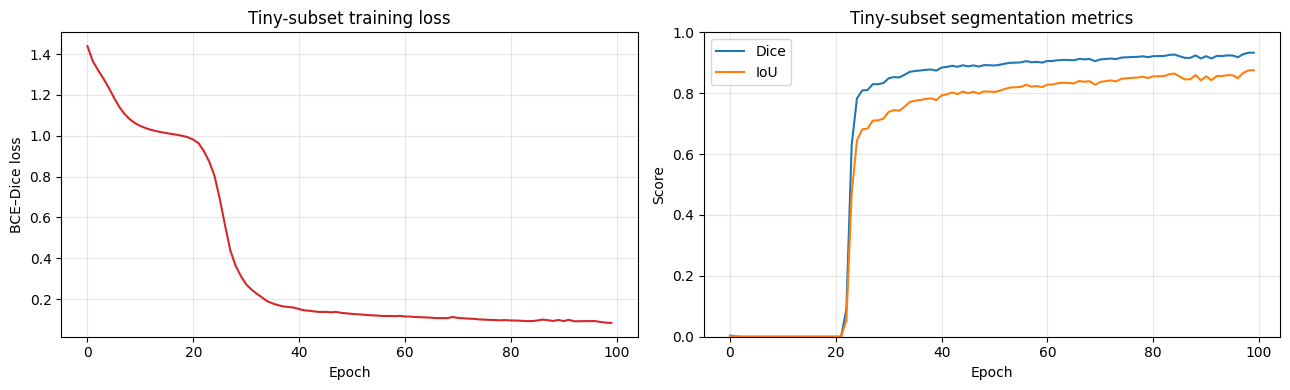

Loss decreased: True
Dice increased: True
IoU increased:  True

Basic overfitting test passed.
Strong result: the model nearly memorized the tiny dataset.


In [ ]:
import matplotlib.pyplot as plt

initial_loss = overfit_history["loss"][0]
final_loss = overfit_history["loss"][-1]

initial_dice = overfit_history["dice"][0]
final_dice = overfit_history["dice"][-1]

initial_iou = overfit_history["iou"][0]
final_iou = overfit_history["iou"][-1]

print("Tiny-subset overfitting results")
print("--------------------------------")
print(
    f"Loss: {initial_loss:.6f} "
    f"→ {final_loss:.6f}"
)
print(
    f"Dice: {initial_dice:.4f} "
    f"→ {final_dice:.4f}"
)
print(
    f"IoU:  {initial_iou:.4f} "
    f"→ {final_iou:.4f}"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4),
)

axes[0].plot(
    overfit_history["loss"],
    color="tab:red",
)

axes[0].set_title(
    "Tiny-subset training loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE–Dice loss")
axes[0].grid(alpha=0.3)

axes[1].plot(
    overfit_history["dice"],
    label="Dice",
)

axes[1].plot(
    overfit_history["iou"],
    label="IoU",
)

axes[1].set_title(
    "Tiny-subset segmentation metrics"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

loss_decreased = final_loss < initial_loss
dice_increased = final_dice > initial_dice
iou_increased = final_iou > initial_iou

print(f"Loss decreased: {loss_decreased}")
print(f"Dice increased: {dice_increased}")
print(f"IoU increased:  {iou_increased}")

if (
    loss_decreased
    and dice_increased
    and iou_increased
):
    print(
        "\nBasic overfitting test passed."
    )

    if final_dice >= 0.90:
        print(
            "Strong result: the model nearly memorized "
            "the tiny dataset."
        )
    else:
        print(
            "The direction is correct, but consider "
            "running more epochs if Dice is still low."
        )
else:
    print(
        "\nDo not begin full training yet. "
        "The pipeline requires debugging."
    )

In [ ]:
# Training configuration and reproducibility
import csv
import json
import random
import time
from pathlib import Path

import numpy as np
import torch
from tqdm.auto import tqdm


# Confirm that the required earlier objects exist.
required_objects = [
    "UNext",
    "BCEDiceLoss",
    "binary_segmentation_metrics",
    "train_loader",
    "val_loader",
    "test_loader",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the earlier cells first. Missing objects: "
        + ", ".join(missing_objects)
    )


SEED = 42
MAX_EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
EARLY_STOPPING_PATIENCE = 15
MIN_DICE_IMPROVEMENT = 1e-4
GRADIENT_CLIP_NORM = 5.0

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

print(f"Device: {DEVICE}")
print(f"Mixed precision: {USE_AMP}")
print(f"Maximum epochs: {MAX_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

if DEVICE.type != "cuda":
    print(
        "\nWARNING: A GPU is not active. In Colab, select:"
        "\nRuntime → Change runtime type → T4 GPU"
    )

Device: cuda
Mixed precision: True
Maximum epochs: 100
Learning rate: 0.0001


In [ ]:
# configure google drive output paths
RUN_NAME = "BreastDM_UNeXt_256"

RUN_DIRECTORY = Path(
    "/content/drive/MyDrive/"
    "BreastDM_Project/UNeXt_runs"
) / RUN_NAME

RUN_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

BEST_CHECKPOINT_PATH = (
    RUN_DIRECTORY / "best_model.pt"
)

RECOVERY_CHECKPOINT_PATH = (
    RUN_DIRECTORY / "recovery_checkpoint.pt"
)

HISTORY_CSV_PATH = (
    RUN_DIRECTORY / "training_history.csv"
)

CONFIG_PATH = (
    RUN_DIRECTORY / "training_config.json"
)

TEST_RESULTS_PATH = (
    RUN_DIRECTORY / "test_results.json"
)

training_config = {
    "run_name": RUN_NAME,
    "seed": SEED,
    "image_height": IMAGE_HEIGHT,
    "image_width": IMAGE_WIDTH,
    "batch_size": BATCH_SIZE,
    "maximum_epochs": MAX_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE
    ),
    "minimum_dice_improvement": (
        MIN_DICE_IMPROVEMENT
    ),
    "gradient_clip_norm": (
        GRADIENT_CLIP_NORM
    ),
    "loss": "0.5 * BCEWithLogits + Dice",
    "optimizer": "Adam",
    "scheduler": "ReduceLROnPlateau",
    "input_channels": 3,
    "output_channels": 1,
    "prediction_threshold": 0.5,
    "mixed_precision": USE_AMP,
    "train_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "test_samples": len(test_dataset),
}

with CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as config_file:
    json.dump(
        training_config,
        config_file,
        indent=2,
    )

print(f"Run directory:\n{RUN_DIRECTORY}")
print(f"\nConfiguration saved to:\n{CONFIG_PATH}")

Run directory:
/content/drive/MyDrive/BreastDM_Project/UNeXt_runs/BreastDM_UNeXt_256

Configuration saved to:
/content/drive/MyDrive/BreastDM_Project/UNeXt_runs/BreastDM_UNeXt_256/training_config.json


In [ ]:
# create fresh model and training components
# do not use the tiny subset for the overfit model for full training for obvious reasons
if "overfit_model" in globals():
    del overfit_model

if "overfit_optimizer" in globals():
    del overfit_optimizer

if torch.cuda.is_available():
    torch.cuda.empty_cache()


model = UNext(
    num_classes=1,
    input_channels=3,
    embedding_dimensions=(32, 64, 128),
    dropout=0.0,
    drop_path_rate=0.0,
).to(DEVICE)


criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=1.0,
    smooth=1e-5,
)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)


total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters:     {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Initial learning rate: {LEARNING_RATE}")

Total parameters:     253,561
Trainable parameters: 253,561
Initial learning rate: 0.0001


In [ ]:
# define the training and evaluration functions
def run_segmentation_epoch(
    model,
    loader,
    criterion,
    device,
    training,
    optimizer=None,
    scaler=None,
    gradient_clip_norm=None,
    description="Epoch",
):
    """
    Run one complete training, validation, or testing epoch.
    """

    if training:
        if optimizer is None or scaler is None:
            raise ValueError(
                "Training requires an optimizer and scaler."
            )

        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    samples_seen = 0

    progress_bar = tqdm(
        loader,
        desc=description,
        leave=False,
    )

    for images, masks, metadata in progress_bar:
        images = images.to(
            device,
            non_blocking=True,
        )

        masks = masks.to(
            device,
            non_blocking=True,
        ).float()

        current_batch_size = images.shape[0]

        if training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(training):
            with torch.amp.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits = model(images)

                if logits.shape != masks.shape:
                    raise RuntimeError(
                        f"Model output {tuple(logits.shape)} "
                        f"does not match masks "
                        f"{tuple(masks.shape)}."
                    )

                loss = criterion(
                    logits,
                    masks,
                )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "A non-finite loss was encountered."
                )

            if training:
                scaler.scale(loss).backward()

                scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=gradient_clip_norm,
                )

                scaler.step(optimizer)
                scaler.update()

        metrics = binary_segmentation_metrics(
            logits.detach(),
            masks,
            threshold=0.5,
        )

        running_loss += (
            loss.item() * current_batch_size
        )

        running_dice += (
            metrics["dice"] * current_batch_size
        )

        running_iou += (
            metrics["iou"] * current_batch_size
        )

        samples_seen += current_batch_size

        progress_bar.set_postfix(
            loss=f"{running_loss / samples_seen:.4f}",
            dice=f"{running_dice / samples_seen:.4f}",
        )

    if samples_seen == 0:
        raise RuntimeError(
            "The data loader returned no samples."
        )

    return {
        "loss": running_loss / samples_seen,
        "dice": running_dice / samples_seen,
        "iou": running_iou / samples_seen,
    }


def write_history_csv(
    history,
    destination,
):
    columns = [
        "epoch",
        "learning_rate",
        "train_loss",
        "train_dice",
        "train_iou",
        "val_loss",
        "val_dice",
        "val_iou",
        "epoch_seconds",
    ]

    with Path(destination).open(
        "w",
        newline="",
        encoding="utf-8",
    ) as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=columns,
        )

        writer.writeheader()
        writer.writerows(history)


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


In [ ]:
# configure checkpoint recovery
RESUME_TRAINING = False

start_epoch = 0
best_validation_dice = -1.0
epochs_without_improvement = 0
training_history = []


if RESUME_TRAINING:
    if not RECOVERY_CHECKPOINT_PATH.is_file():
        raise FileNotFoundError(
            "Resume was requested, but no recovery "
            f"checkpoint exists:\n{RECOVERY_CHECKPOINT_PATH}"
        )

    print("Loading recovery checkpoint...")

    checkpoint = torch.load(
        RECOVERY_CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    scheduler.load_state_dict(
        checkpoint["scheduler_state_dict"]
    )

    scaler.load_state_dict(
        checkpoint["scaler_state_dict"]
    )

    start_epoch = checkpoint["epoch"]
    best_validation_dice = checkpoint[
        "best_validation_dice"
    ]

    epochs_without_improvement = checkpoint[
        "epochs_without_improvement"
    ]

    training_history = checkpoint[
        "training_history"
    ]

    loader_generator_state = checkpoint.get(
        "loader_generator_state"
    )

    if (
        loader_generator_state is not None
        and getattr(
            train_loader,
            "generator",
            None,
        ) is not None
    ):
        train_loader.generator.set_state(
            loader_generator_state
        )

    print(
        f"Training will resume at epoch "
        f"{start_epoch + 1}."
    )

    print(
        f"Best validation Dice so far: "
        f"{best_validation_dice:.4f}"
    )

else:
    print("Starting a new training run.")

Starting a new training run.


In [ ]:
# run full unext training
# this should take a while
print("Beginning full UNeXt training...")
print(f"Results will be saved to:\n{RUN_DIRECTORY}\n")


for epoch_index in range(
    start_epoch,
    MAX_EPOCHS,
):
    epoch_number = epoch_index + 1
    epoch_start_time = time.time()

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    print(
        f"\nEpoch {epoch_number}/{MAX_EPOCHS} "
        f"| Learning rate: "
        f"{current_learning_rate:.2e}"
    )

    train_metrics = run_segmentation_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        device=DEVICE,
        training=True,
        optimizer=optimizer,
        scaler=scaler,
        gradient_clip_norm=(
            GRADIENT_CLIP_NORM
        ),
        description=(
            f"Train {epoch_number}"
        ),
    )

    val_metrics = run_segmentation_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        training=False,
        description=(
            f"Val {epoch_number}"
        ),
    )

    scheduler.step(
        val_metrics["loss"]
    )

    epoch_seconds = (
        time.time() - epoch_start_time
    )

    history_record = {
        "epoch": epoch_number,
        "learning_rate": current_learning_rate,
        "train_loss": train_metrics["loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "val_loss": val_metrics["loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
        "epoch_seconds": epoch_seconds,
    }

    training_history.append(
        history_record
    )

    validation_improved = (
        val_metrics["dice"]
        > best_validation_dice
        + MIN_DICE_IMPROVEMENT
    )

    if validation_improved:
        best_validation_dice = (
            val_metrics["dice"]
        )

        epochs_without_improvement = 0

        print(
            "Validation Dice improved. "
            "Saving the best model."
        )

    else:
        epochs_without_improvement += 1

    loader_generator_state = None

    if getattr(
        train_loader,
        "generator",
        None,
    ) is not None:
        loader_generator_state = (
            train_loader.generator.get_state()
        )

    checkpoint = {
        "epoch": epoch_number,
        "model_state_dict": (
            model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "scheduler_state_dict": (
            scheduler.state_dict()
        ),
        "scaler_state_dict": (
            scaler.state_dict()
        ),
        "best_validation_dice": (
            best_validation_dice
        ),
        "epochs_without_improvement": (
            epochs_without_improvement
        ),
        "training_history": (
            training_history
        ),
        "loader_generator_state": (
            loader_generator_state
        ),
        "training_config": (
            training_config
        ),
    }

    # Always save the latest completed epoch.
    torch.save(
        checkpoint,
        RECOVERY_CHECKPOINT_PATH,
    )

    # Save a separate checkpoint whenever validation improves.
    if validation_improved:
        torch.save(
            checkpoint,
            BEST_CHECKPOINT_PATH,
        )

    write_history_csv(
        training_history,
        HISTORY_CSV_PATH,
    )

    print(
        f"Train | "
        f"Loss: {train_metrics['loss']:.5f} | "
        f"Dice: {train_metrics['dice']:.4f} | "
        f"IoU: {train_metrics['iou']:.4f}"
    )

    print(
        f"Val   | "
        f"Loss: {val_metrics['loss']:.5f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f}"
    )

    print(
        f"Best validation Dice: "
        f"{best_validation_dice:.4f}"
    )

    print(
        f"Epoch time: "
        f"{epoch_seconds / 60:.2f} minutes"
    )

    print(
        "Epochs without improvement: "
        f"{epochs_without_improvement}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping activated."
        )
        break


print("\nTraining finished.")
print(f"Best validation Dice: {best_validation_dice:.4f}")
print(f"Best checkpoint:\n{BEST_CHECKPOINT_PATH}")

Beginning full UNeXt training...
Results will be saved to:
/content/drive/MyDrive/BreastDM_Project/UNeXt_runs/BreastDM_UNeXt_256


Epoch 1/100 | Learning rate: 1.00e-04


Train 1:   0%|          | 0/2553 [00:00<?, ?it/s]

Val 1:   0%|          | 0/572 [00:00<?, ?it/s]

Validation Dice improved. Saving the best model.
Train | Loss: 0.68298 | Dice: 0.3973 | IoU: 0.3097
Val   | Loss: 0.47599 | Dice: 0.5418 | IoU: 0.4314
Best validation Dice: 0.5418
Epoch time: 3.24 minutes
Epochs without improvement: 0/15

Epoch 2/100 | Learning rate: 1.00e-04


Train 2:   0%|          | 0/2553 [00:00<?, ?it/s]

...

Val 17:   0%|          | 0/572 [00:00<?, ?it/s]

Train | Loss: 0.17386 | Dice: 0.8317 | IoU: 0.7347
Val   | Loss: 0.50551 | Dice: 0.5069 | IoU: 0.4253
Best validation Dice: 0.5455
Epoch time: 2.93 minutes
Epochs without improvement: 14/15

Epoch 18/100 | Learning rate: 2.50e-05


Train 18:   0%|          | 0/2553 [00:00<?, ?it/s]

Val 18:   0%|          | 0/572 [00:00<?, ?it/s]

Train | Loss: 0.17216 | Dice: 0.8333 | IoU: 0.7367
Val   | Loss: 0.51640 | Dice: 0.4971 | IoU: 0.4172
Best validation Dice: 0.5455
Epoch time: 2.89 minutes
Epochs without improvement: 15/15

Early stopping activated.

Training finished.
Best validation Dice: 0.5455
Best checkpoint:
/content/drive/MyDrive/BreastDM_Project/UNeXt_runs/BreastDM_UNeXt_256/best_model.pt


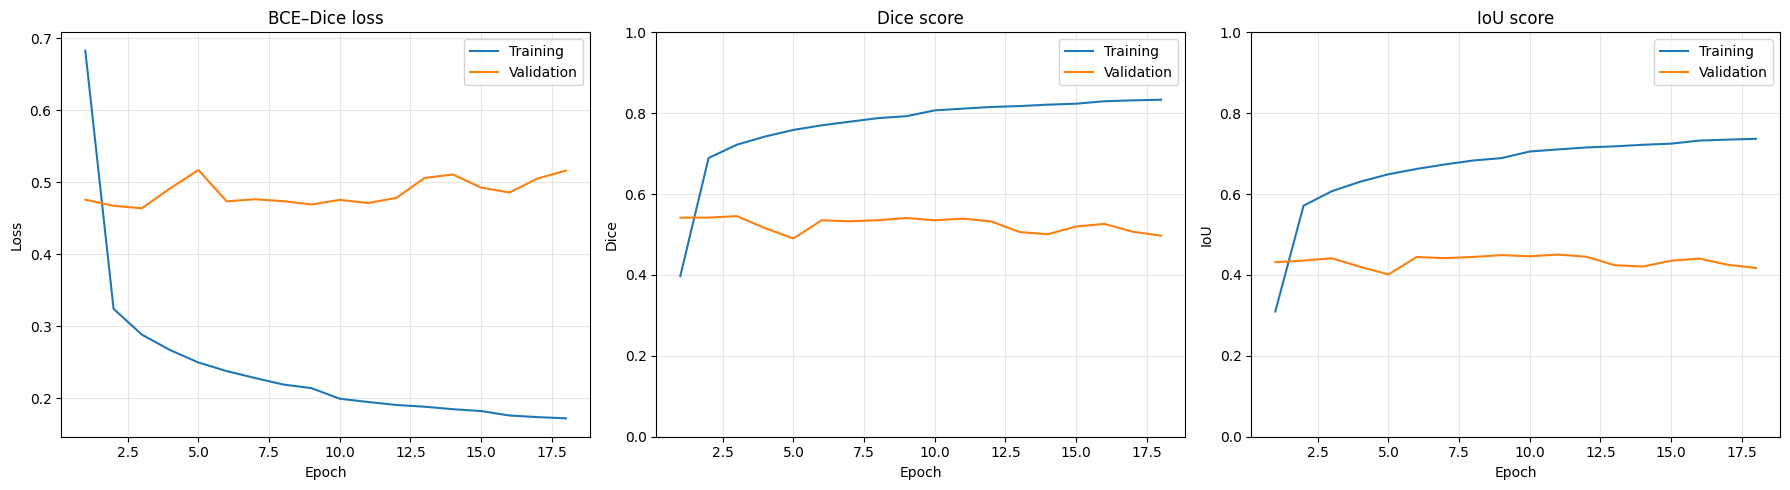

Training curves saved to:
/content/drive/MyDrive/BreastDM_Project/UNeXt_runs/BreastDM_UNeXt_256/training_curves.png


In [ ]:
# plot the training history so i can see it in action
import matplotlib.pyplot as plt

if not training_history:
    raise RuntimeError(
        "No training history is available."
    )

epochs = [
    record["epoch"]
    for record in training_history
]

train_losses = [
    record["train_loss"]
    for record in training_history
]

val_losses = [
    record["val_loss"]
    for record in training_history
]

train_dice = [
    record["train_dice"]
    for record in training_history
]

val_dice = [
    record["val_dice"]
    for record in training_history
]

train_iou = [
    record["train_iou"]
    for record in training_history
]

val_iou = [
    record["val_iou"]
    for record in training_history
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

axes[0].plot(
    epochs,
    train_losses,
    label="Training",
)

axes[0].plot(
    epochs,
    val_losses,
    label="Validation",
)

axes[0].set_title("BCE–Dice loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    epochs,
    train_dice,
    label="Training",
)

axes[1].plot(
    epochs,
    val_dice,
    label="Validation",
)

axes[1].set_title("Dice score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)


axes[2].plot(
    epochs,
    train_iou,
    label="Training",
)

axes[2].plot(
    epochs,
    val_iou,
    label="Validation",
)

axes[2].set_title("IoU score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("IoU")
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.3)


plt.tight_layout()

CURVES_PATH = (
    RUN_DIRECTORY / "training_curves.png"
)

plt.savefig(
    CURVES_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Training curves saved to:\n{CURVES_PATH}")

In [ ]:
# load the best check point
if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"Best checkpoint not found:\n"
        f"{BEST_CHECKPOINT_PATH}"
    )

best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.eval()

print(
    "Loaded best model from epoch:",
    best_checkpoint["epoch"],
)

print(
    "Best validation Dice:",
    f"{best_checkpoint['best_validation_dice']:.4f}",
)

Loaded best model from epoch: 3
Best validation Dice: 0.5455


In [ ]:
# evaluate the untouched test set
print("Evaluating the best model on the test set...")

test_metrics = run_segmentation_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    training=False,
    description="Test",
)

test_results = {
    "best_epoch": (
        best_checkpoint["epoch"]
    ),
    "best_validation_dice": (
        best_checkpoint[
            "best_validation_dice"
        ]
    ),
    "test_loss": test_metrics["loss"],
    "test_dice": test_metrics["dice"],
    "test_iou": test_metrics["iou"],
    "prediction_threshold": 0.5,
}

with TEST_RESULTS_PATH.open(
    "w",
    encoding="utf-8",
) as results_file:
    json.dump(
        test_results,
        results_file,
        indent=2,
    )

print("\nFinal test results")
print("------------------")
print(f"Loss: {test_metrics['loss']:.6f}")
print(f"Dice: {test_metrics['dice']:.4f}")
print(f"IoU:  {test_metrics['iou']:.4f}")

print(
    f"\nTest results saved to:\n"
    f"{TEST_RESULTS_PATH}"
)

Evaluating the best model on the test set...


Test:   0%|          | 0/536 [00:00<?, ?it/s]


Final test results
------------------
Loss: 0.423182
Dice: 0.5884
IoU:  0.4759

Test results saved to:
/content/drive/MyDrive/BreastDM_Project/UNeXt_runs/BreastDM_UNeXt_256/test_results.json


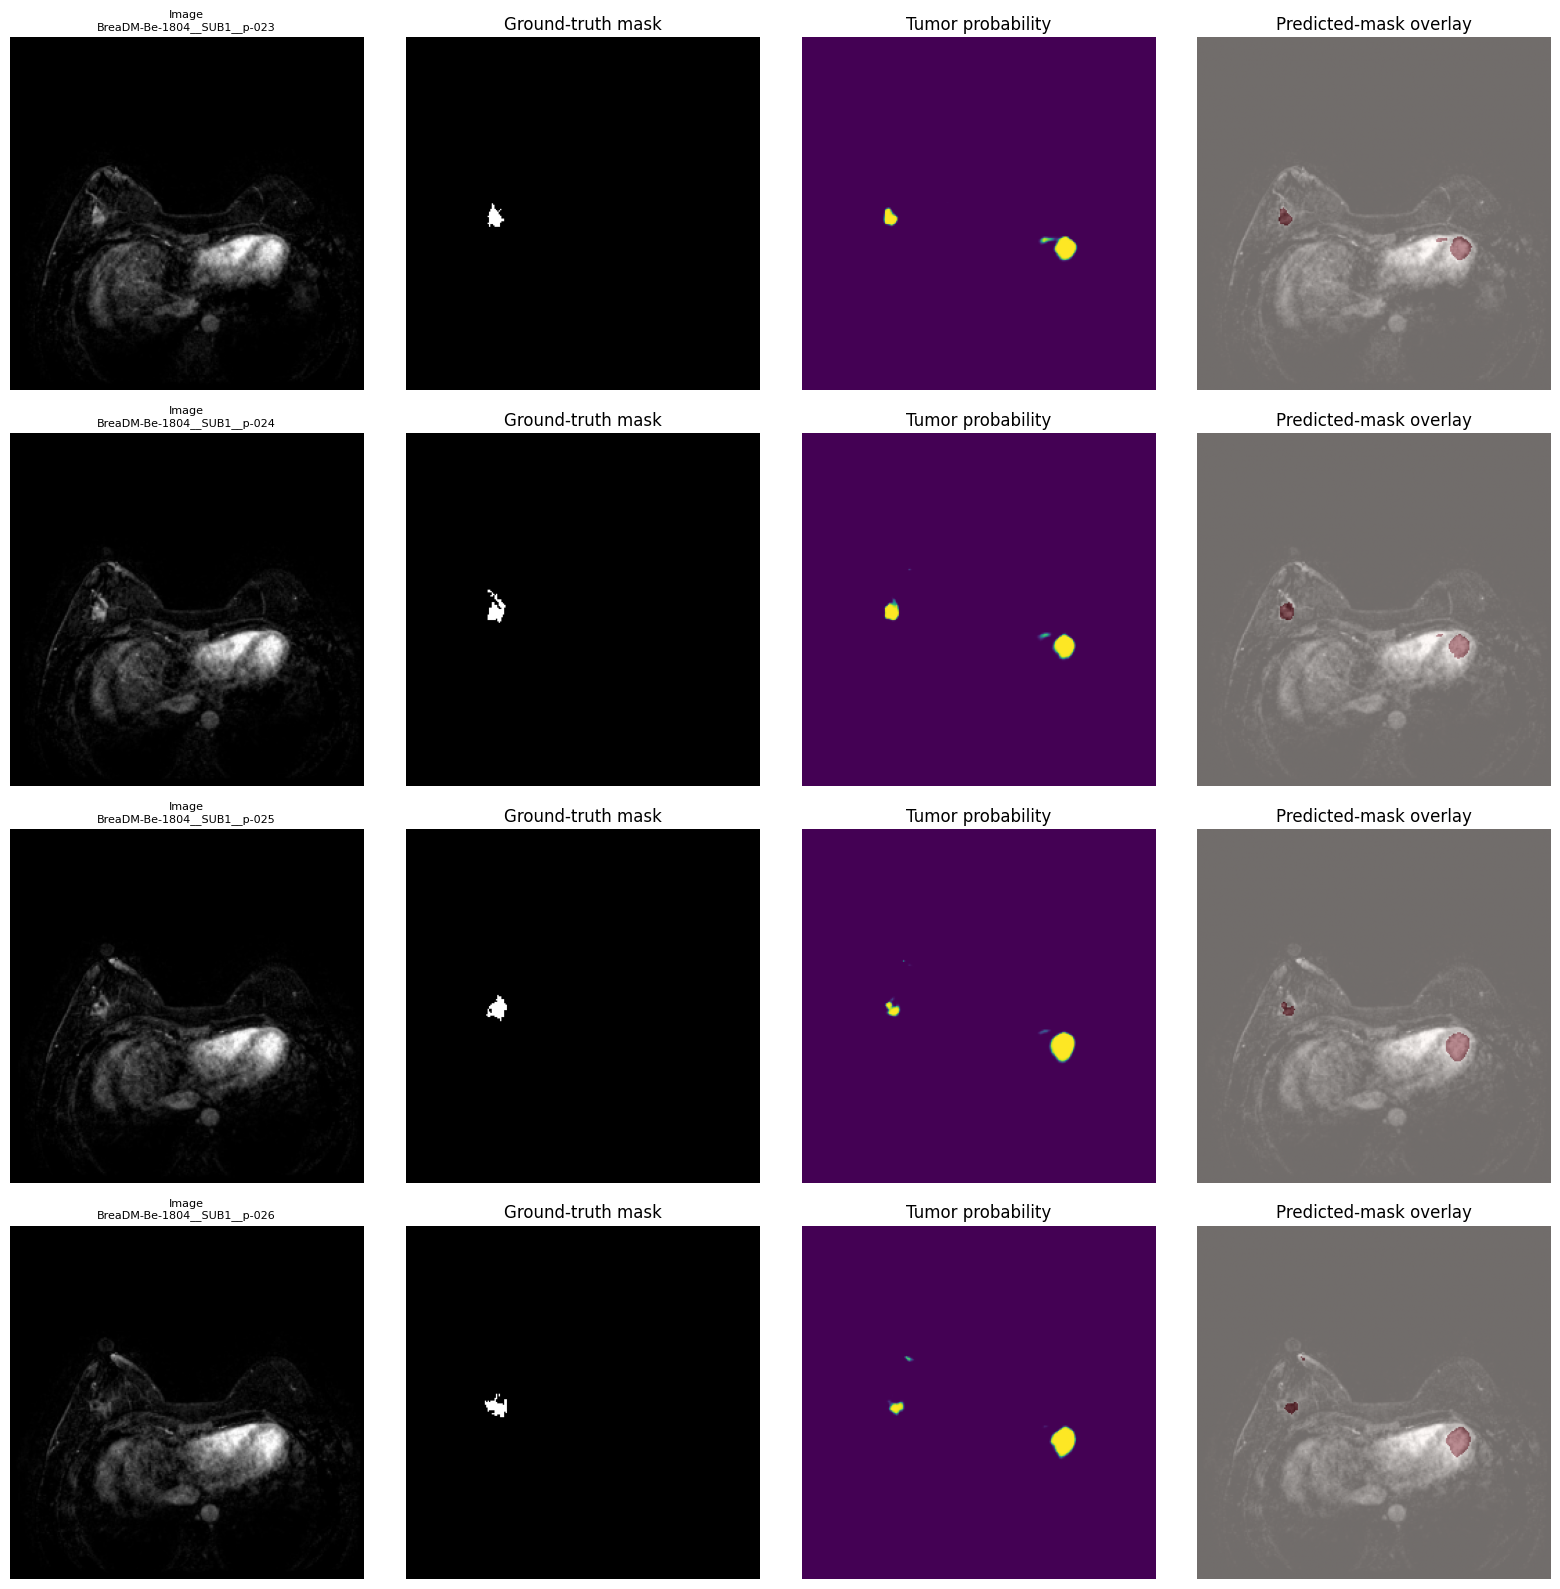

Prediction figure saved to:
/content/drive/MyDrive/BreastDM_Project/UNeXt_runs/BreastDM_UNeXt_256/test_predictions.png


In [ ]:
# visualize the test predictions
import matplotlib.pyplot as plt

model.eval()

test_images, test_masks, test_metadata = next(
    iter(test_loader)
)

display_count = min(
    4,
    test_images.shape[0],
)

with torch.no_grad():
    test_logits = model(
        test_images.to(
            DEVICE,
            non_blocking=True,
        )
    )

    test_probabilities = torch.sigmoid(
        test_logits
    ).cpu()

    test_predictions = (
        test_probabilities >= 0.5
    ).float()


fig, axes = plt.subplots(
    display_count,
    4,
    figsize=(16, 4 * display_count),
)

if display_count == 1:
    axes = axes.reshape(1, -1)


for row in range(display_count):
    image = (
        test_images[row]
        .permute(1, 2, 0)
        .numpy()
    )

    true_mask = (
        test_masks[row]
        .squeeze(0)
        .numpy()
    )

    probability = (
        test_probabilities[row]
        .squeeze(0)
        .numpy()
    )

    prediction = (
        test_predictions[row]
        .squeeze(0)
        .numpy()
    )

    sample_id = test_metadata[
        "img_id"
    ][row]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(
        f"Image\n{sample_id}",
        fontsize=8,
    )

    axes[row, 1].imshow(
        true_mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row, 1].set_title("Ground-truth mask")

    axes[row, 2].imshow(
        probability,
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axes[row, 2].set_title(
        "Tumor probability"
    )

    axes[row, 3].imshow(image)
    axes[row, 3].imshow(
        prediction,
        cmap="Reds",
        alpha=0.45,
        vmin=0,
        vmax=1,
    )
    axes[row, 3].set_title(
        "Predicted-mask overlay"
    )

    for column in range(4):
        axes[row, column].axis("off")


plt.tight_layout()

PREDICTIONS_PATH = (
    RUN_DIRECTORY / "test_predictions.png"
)

plt.savefig(
    PREDICTIONS_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    f"Prediction figure saved to:\n"
    f"{PREDICTIONS_PATH}"
)

In [ ]:
# important note:If Colab disconnects, rerun all definition/setup cells, set RESUME_TRAINING = True in Cell 26, and rerun Cells 26–27. The recovery checkpoint resumes from the last completed epoch.
# also remember to put all this in project notes
